# Kernel PCA


### Linear PCA
$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$

PCA is an unsupervised Machine Learning technique that learns a low-dimentional representation of the data.


We have a set $x_1,\ldots, x_m$ of vectors in $\RR^n$.

We project them to a lower dimention subspace spanned by the orthonormal vectors $v_1,\ldots,  v_k$.
For a single vector $x$, the projection is 
$$
 P_V(x_i) = \sum_{i=1}^k \pair{x, v_i} v_i
$$
In matrix form, the orthogonal projection onto the span of $v$ is

$$
 P_V = V^TV
$$
where 
$
 V = \lbrack v_1, \dots,  v_k \rbrack^T
$
satisfies $VV^T = I_k$. (since the $v_j$ are orthonormal).

In PCA, we try to find a subspace of dimensions $k$ such that the projection on this subspace is as close as possible to the original data, that is we solve:

$$
\min_{V} \frac{1}{2}\norm{X - V^TVX}^2
$$
over the orthonormal matrices $V$.
Apply pythagoria's theorem to split the norm:
$$
\frac{1}{2}\norm{X - V^TVX}^2 = \quad \frac{1}{2}\norm{X}^2 + \frac{1}{2}\norm{V^TV X}^2 - \pair{X, V^TVX}.
$$

The first term is constant with respect to $V$.
The second term is equal to $(1/2)\norm{V X}^2$ by isometry, and the last term 
is $-\norm{VX}^2$.

Therfore the objective is also
$$
    \max_{V} \norm{VX}^2 = \max_{V} \trace{VX^TXV^T}
$$

We can show that in the last expression that $V$ is the top $k$-components of the 
eigen decomposition of $XX^T$.

### PCA in a RKHS:

$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$
$\def\XX{\mathcal{X}}\def\HH{\mathcal{H}}$

We can proceed as before except that we try to find a $k$ dimentionnal representation of the vectors in the RKHS $\phi(x_1),...,\phi(x_n)$. The only difficulty is that those vectors are of infinite dimensions. 

Let's first focus on the projection over a single vector ($k=1$). For a  unitary vector $f\in \HH$, $\norm{f}^2 = 1$, we can still define the projection 
$$
P_f: \HH\to \HH ,\ g \mapsto \pair {g, f}f
$$
And the optimal vector is 
$$
f^* = \argmin_{f \in \mathcal{H}, ||f|| = 1} \sum_{i=1}^n || P_f(\phi(x_i)) - \phi(x_i)||_\mathcal{H}^2
$$

Q1) Prove that 

$$
f^* = \argmax_{f \in \mathcal{H}, ||f|| = 1} \sum_{i=1}^n f(x_i)^2
$$

(Tip: remember the reproducing property !)

Q2) Let's prove a variant of the representer theorem for this new optimization problem. We split $\HH$ into the span of the $\phi(x_1),\ldots,\phi(x_m)$ and its complement, that is for each $f \in \mathcal{H}$ we denote 

$$ f = f_X + f_\bot$$

where $f_X = \sum \alpha_i \phi(x_i)$ and $\langle f_\bot, f_X \rangle = 0$.

Prove the representer theorem i.e. that the optimal $f$ satisfies $f_\bot  = 0$.

Q3) Apply the representer theorem to get a optimization problem over $\alpha \in \mathbb{R}^n$. As always the problem should depend only on $\alpha$ and the kernel matrix $K$.

Q4) Use the change of variable $\beta = \sqrt{K} \alpha$ to rewrite the problem as an eigenvalue problem.

Q5) Let's say that we have found the $k$ principal vectors $f_1,...,f_k$ and that they all have the form

$$f_j = \sum_i \alpha_{i,j} \phi(x_i)$$

We are now given an new point $x$ (not necessarily in the train set). Give the expression of the $k$ principal components of $\phi(x)$:

$$ f_j(x) = \langle \phi(x), f_j \rangle$$

Give the expression of vector $f(x)$ depending on the matrix $\alpha$ and the vector $k_x = [k(x,x_1),...,k(x,x_n)]$

In conclusion, the algorithm for kernel PCA is :

* compute the gram matrix and center it.
* decompose it, keep the first $k$ eigenvectors, and eigenvalues.
* At a test point $x$, compute the k principal components.

### Code Session

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

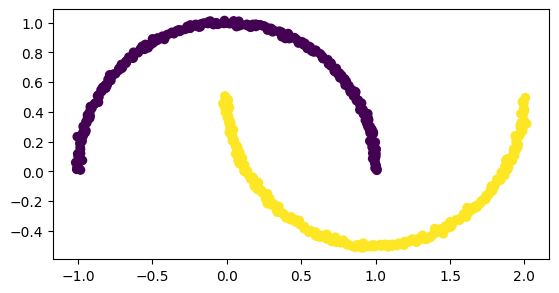

In [22]:
random_state = 17
n_samples = 500
X, y = make_moons(n_samples=n_samples, noise=0.01, random_state=random_state)
#X, y = make_circles(n_samples=n_samples, noise=0.01, factor=0.3, random_state=random_state)
#X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=1.0, random_state=random_state)

fig, ax = plt.subplots()
_ = ax.scatter(X[:,0], X[:,1], c=y)
ax.set_aspect('equal')

In [23]:
def make_grid(n,X):
    """
        Generates a grid of points within the bounds of the given data.

        n : int
            The number of points along each dimension of the grid.
        X : numpy.ndarray
            A 2D array of shape (num_samples, 2) representing the input data.

        numpy.ndarray
            A 2D array of shape (n*n, 2) containing the grid points.
    """
    x_min, y_min = np.min(X, axis=0)
    x_max, y_max = np.max(X, axis=0)
    xy = np.mgrid[x_min:x_max:1j*n, y_min:y_max:1j*n].reshape(2,-1).T
    return xy

In [24]:
class Kernel():
    
    def compute_norm_f(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            norm_f: float
        '''
        
        norm_f = alpha.T @ Kxx @ alpha
        
        return norm_f
    
    def compute_prediction_train(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (n)
        '''
        
        y =  Kxx @ alpha
        
        return y
    
    def compute_prediction_test(self, Kxz, alpha):
        '''
        Input: 
            Kxz: numpy array of shape (n, m)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (m)
        '''
        
        y = Kxz.T @ alpha
        
        return y
    
    
class GaussianKernel(Kernel):
    
    def __init__(self, sigma = 1):
        self.sigma = sigma
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        X_norm2 = np.sum(X**2, axis=1, keepdims=True) # (n,1)
        D2 = X_norm2 + X_norm2.T - 2 * (X @ X.T)     # (n,n)
        Kxx = np.exp(-D2 / (2.0 * self.sigma**2))

        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        X_norm2 = np.sum(X**2, axis=1, keepdims=True)   # (n,1)
        Z_norm2 = np.sum(Z**2, axis=1, keepdims=True)   # (m,1)
        D2 = X_norm2 + Z_norm2.T - 2 * (X @ Z.T)        # (n,m)
        Kxz = np.exp(-D2 / (2.0 * self.sigma**2))
        
        
        return Kxz
    
class LinearKernel(Kernel):
    
    def __init__(self):
        pass
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        Kxx = X @ X.T
        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        Kxz = X @ Z.T
        
        return Kxz

In [25]:
# Hyperparameters (to be tuned)
kernel = 'linear' # test 'linear' or 'gaussian'
sigma = 1 
lbda = 0.1

# Define kernel
if kernel == 'linear':
    kernel = LinearKernel()
elif kernel == 'gaussian':
    kernel = GaussianKernel(sigma = sigma)
else:
    raise ValueError('Unknown kernel')


def KPCA_representation(X):
    """
    Compute the finite-dimensional representation of the principal components.

    Parameters
    ----------
    X : (n, d) numpy.ndarray
        The input data.

    Returns
    -------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components.
    """
    # get the kernel matrix, center it, get the eigenvectors and eigenvalues, change the variables.
    n = X.shape[0]
    Kxx = kernel.get_Kxx(X)
    one_n = np.ones((n, n)) / n
    # Center Kxx_c = H Kxx H where H = I - 1_n
    H = np.eye(n) - one_n
    Kxx_c = H @ Kxx @ H
    # Regularization and eigen decomposition
    Kxx_c = Kxx_c + lbda * np.eye(n)
    eigvals, eigvecs = np.linalg.eigh(Kxx_c)
    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_indices]
    eigvecs = eigvecs[:, sorted_indices]
    # Select the top k eigenvectors (principal components)
    k = 2
    eigvecs = eigvecs[:, :k]
    eigvals = eigvals[:k]
    # Compute the finite-dimensional representation
    alpha = eigvecs / np.sqrt(eigvals + 1e-10)  # Add a small constant to avoid division by zero
    return alpha

In [26]:
def principal_component(alpha, X, Z):
    """
    return the evaluation of the principal components at points Z.

    Parameters
    ----------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components
    X: (n, d) numpy.ndarray
        The input data.
    Z : (m, n) array
        points to where to evaluate the principal components.

    Returns
    -------
    (k, m) array
        value of the k principal components at points y.
    """
    Kxz = kernel.get_Kxz(X, Z)
    Kxx = kernel.get_Kxx(X)

    n, m = Kxz.shape
    Kxx_row_mean = Kxx.mean(axis=1, keepdims=True)    # (n,1)
    Kxz_col_mean = Kxz.mean(axis=0, keepdims=True)    # (1,m)
    Kxx_mean = Kxx.mean()                              

    Kxz_c = (
        Kxz
        - Kxx_row_mean @ np.ones((1, m))
        - np.ones((n, 1)) @ Kxz_col_mean
        + Kxx_mean
    )  # (n, m)

    pc = alpha.T @ Kxz_c   # (k, m)
    return pc


In [27]:
n_eval = 200
Z = make_grid(n_eval, X)

alpha = KPCA_representation(X)
principal_component_fn = lambda E: principal_component(alpha, X, E)
# feval = principal_component(Z)
# fself = principal_component(X)
feval = principal_component_fn(Z)
fself = principal_component_fn(X)

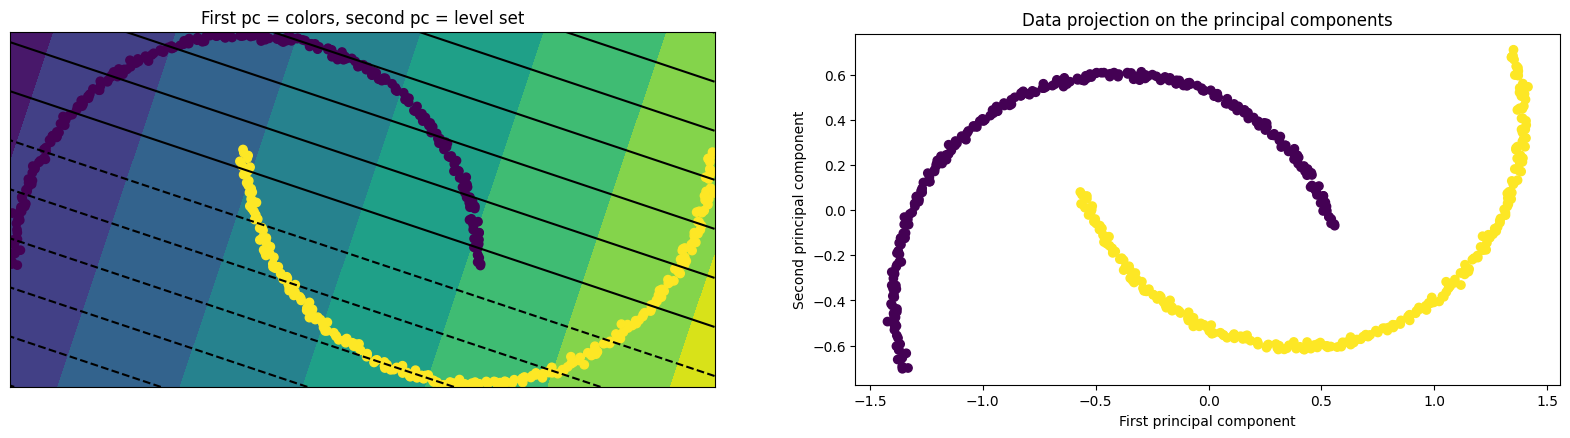

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
Ep = Z.T.reshape((2, n_eval, n_eval))
fxp = feval.reshape((feval.shape[0], n_eval, n_eval))
_ = ax1.contourf(Ep[0], Ep[1], fxp[0])
_ = ax1.contour(Ep[0], Ep[1], fxp[1], colors='black', levels=12 )
_ = ax1.scatter(X[:,0], X[:,1], c=y)
ax2.scatter(fself[0], fself[1], c=y)
ax1.xaxis.set_visible(False)
ax1.yaxis.set_visible(False)
#ax2.xaxis.set_visible(False)
#ax2.yaxis.set_visible(False)
ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax1.set_title('First pc = colors, second pc = level set')
ax2.set_title('Data projection on the principal components')
ax2.set_xlabel('First principal component')
ax2.set_ylabel('Second principal component')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.show()